In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from matplotlib.colors import ListedColormap

In [2]:
correlation_directory = "../2024_Nov/HiExpr_correlation_info_matrix/"

In [3]:
csv_paths_list = []
# Loop through the inner directories and files
for root, dirs, files in os.walk(correlation_directory):
    # Skip the root directory itself
    if root == correlation_directory:
        continue
    
    # Loop through the files in the current inner directory
    for file in files:
        if file.endswith('.csv'):
            # Get the full path and store it
            full_path = os.path.join(root, file)
            csv_paths_list.append(full_path)

csv_paths_list = sorted(csv_paths_list)

### change this part if you have changed the directory

In [4]:
from statsmodels.stats.multitest import multipletests

categories = []
# counts = []
concatenated = pd.DataFrame()

for file_path in csv_paths_list:
    all_dataframes = {}
    organ_name = file_path.split("/")[3].split("_")[2]
    if (file_path.endswith('.csv')):
        name = file_path.split("/")[-1].split("_")[2]
        df = pd.read_csv(file_path, index_col=0)
        df = df.dropna()
        df['Category'] = "_".join([organ_name, name])
        concatenated = pd.concat([concatenated, df])

In [5]:
concatenated

,Pearson Correlation,Absolute Correlation,P-values,Category
Rpl27a,0.503730,0.503730,2.912846e-169,Bladder_bladder cell
Rps15,0.520470,0.520470,1.535857e-182,Bladder_bladder cell
Map1lc3b,0.279905,0.279905,1.531039e-48,Bladder_bladder cell
Uba52,0.312121,0.312121,1.601738e-60,Bladder_bladder cell
Cox5b,-0.037507,0.037507,5.444589e-02,Bladder_bladder cell
...,...,...,...,...
Hsd11b1,0.038225,0.038225,8.525891e-02,Lung_stromal cell
Rps29,-0.268350,0.268350,8.664510e-35,Lung_stromal cell
Rps19,-0.149639,0.149639,1.263431e-11,Lung_stromal cell
Rpl15,-0.094779,0.094779,1.909597e-05,Lung_stromal cell


In [6]:
concatenated["Category"].unique()

array(['Bladder_bladder cell', 'Bladder_bladder urothelial cell',
       'Bone-Marrow_erythroblast', 'Bone-Marrow_granulocyte',
       'Bone-Marrow_granulocytopoietic cell',
       'Bone-Marrow_hematopoietic precursor cell',
       'Bone-Marrow_megakaryocyte-erythroid progenitor cell',
       'Bone-Marrow_monocyte', 'Bone-Marrow_naïve T cell',
       'Bone-Marrow_proerythroblast', 'Bone-Marrow_promonocyte',
       'Brain_endothelial cell', 'Brain_microglial cell',
       'Brain_oligodendrocyte',
       'Heart_endothelial cell of coronary artery',
       'Heart_fibroblast of cardiac tissue', 'Heart_leukocyte',
       'Kidney_epithelial cell of proximal tubule',
       'Kidney_fenestrated cell',
       'Kidney_kidney loop of Henle thick ascending limb epithelial cell',
       'Kidney_kidney proximal convoluted tubule epithelial cell',
       'Kidney_macrophage', 'Limb-Muscle_B cell', 'Limb-Muscle_T cell',
       'Limb-Muscle_endothelial cell', 'Limb-Muscle_macrophage',
       'Limb-Muscl

## Using False Discovery Rate (FDR) correction to correct p values and generate more trustworthy results

In [7]:
adj_pvalues = multipletests(np.array(concatenated["P-values"]), method = "fdr_bh")[1]
concatenated["adjP-values"] = adj_pvalues
concatenated

,Pearson Correlation,Absolute Correlation,P-values,Category,adjP-values
Rpl27a,0.503730,0.503730,2.912846e-169,Bladder_bladder cell,7.729637e-166
Rps15,0.520470,0.520470,1.535857e-182,Bladder_bladder cell,5.010140e-179
Map1lc3b,0.279905,0.279905,1.531039e-48,Bladder_bladder cell,3.895305e-46
Uba52,0.312121,0.312121,1.601738e-60,Bladder_bladder cell,5.641907e-58
Cox5b,-0.037507,0.037507,5.444589e-02,Bladder_bladder cell,1.805310e-01
...,...,...,...,...,...
Hsd11b1,0.038225,0.038225,8.525891e-02,Lung_stromal cell,2.471391e-01
Rps29,-0.268350,0.268350,8.664510e-35,Lung_stromal cell,1.352498e-32
Rps19,-0.149639,0.149639,1.263431e-11,Lung_stromal cell,4.037618e-10
Rpl15,-0.094779,0.094779,1.909597e-05,Lung_stromal cell,2.253518e-04


In [8]:
# Cap the values to 1e-10, anything that is more than 1e-10 will be 1e-10
concatenated["adjP-values"] = np.where(
    concatenated["adjP-values"] < 1e-10, 
    1e-10, 
    concatenated["adjP-values"]
)

### do the logp-value here

In [9]:
concatenated["log-adjP-values"] = np.log10(concatenated["adjP-values"])
concatenated

,Pearson Correlation,Absolute Correlation,P-values,Category,adjP-values,log-adjP-values
Rpl27a,0.503730,0.503730,2.912846e-169,Bladder_bladder cell,1.000000e-10,-10.000000
Rps15,0.520470,0.520470,1.535857e-182,Bladder_bladder cell,1.000000e-10,-10.000000
Map1lc3b,0.279905,0.279905,1.531039e-48,Bladder_bladder cell,1.000000e-10,-10.000000
Uba52,0.312121,0.312121,1.601738e-60,Bladder_bladder cell,1.000000e-10,-10.000000
Cox5b,-0.037507,0.037507,5.444589e-02,Bladder_bladder cell,1.805310e-01,-0.743448
...,...,...,...,...,...,...
Hsd11b1,0.038225,0.038225,8.525891e-02,Lung_stromal cell,2.471391e-01,-0.607059
Rps29,-0.268350,0.268350,8.664510e-35,Lung_stromal cell,1.000000e-10,-10.000000
Rps19,-0.149639,0.149639,1.263431e-11,Lung_stromal cell,4.037618e-10,-9.393875
Rpl15,-0.094779,0.094779,1.909597e-05,Lung_stromal cell,2.253518e-04,-3.647139


In [10]:
sig_counts = concatenated[(concatenated['adjP-values'] < 0.05)]
value_matrix = sig_counts.set_index(['Category', sig_counts.index])['Pearson Correlation'].unstack()
value_matrix = value_matrix.fillna(0)

In [11]:
value_matrix = value_matrix.rename(
    index={"Kidney_kidney loop of Henle thick ascending limb epithelial cell": "Kidney TAL epith cell",
          "Bone-Marrow_megakaryocyte-erythroid progenitor cell": "Bone-Marrow MEP cell",
          "Kidney_kidney proximal convoluted tubule epithelial cell": "Kidney_PCT_epith cell"}
)

In [12]:
value_matrix.shape

(36, 16298)

/Users/chanyue/anaconda3/envs/scanpy/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


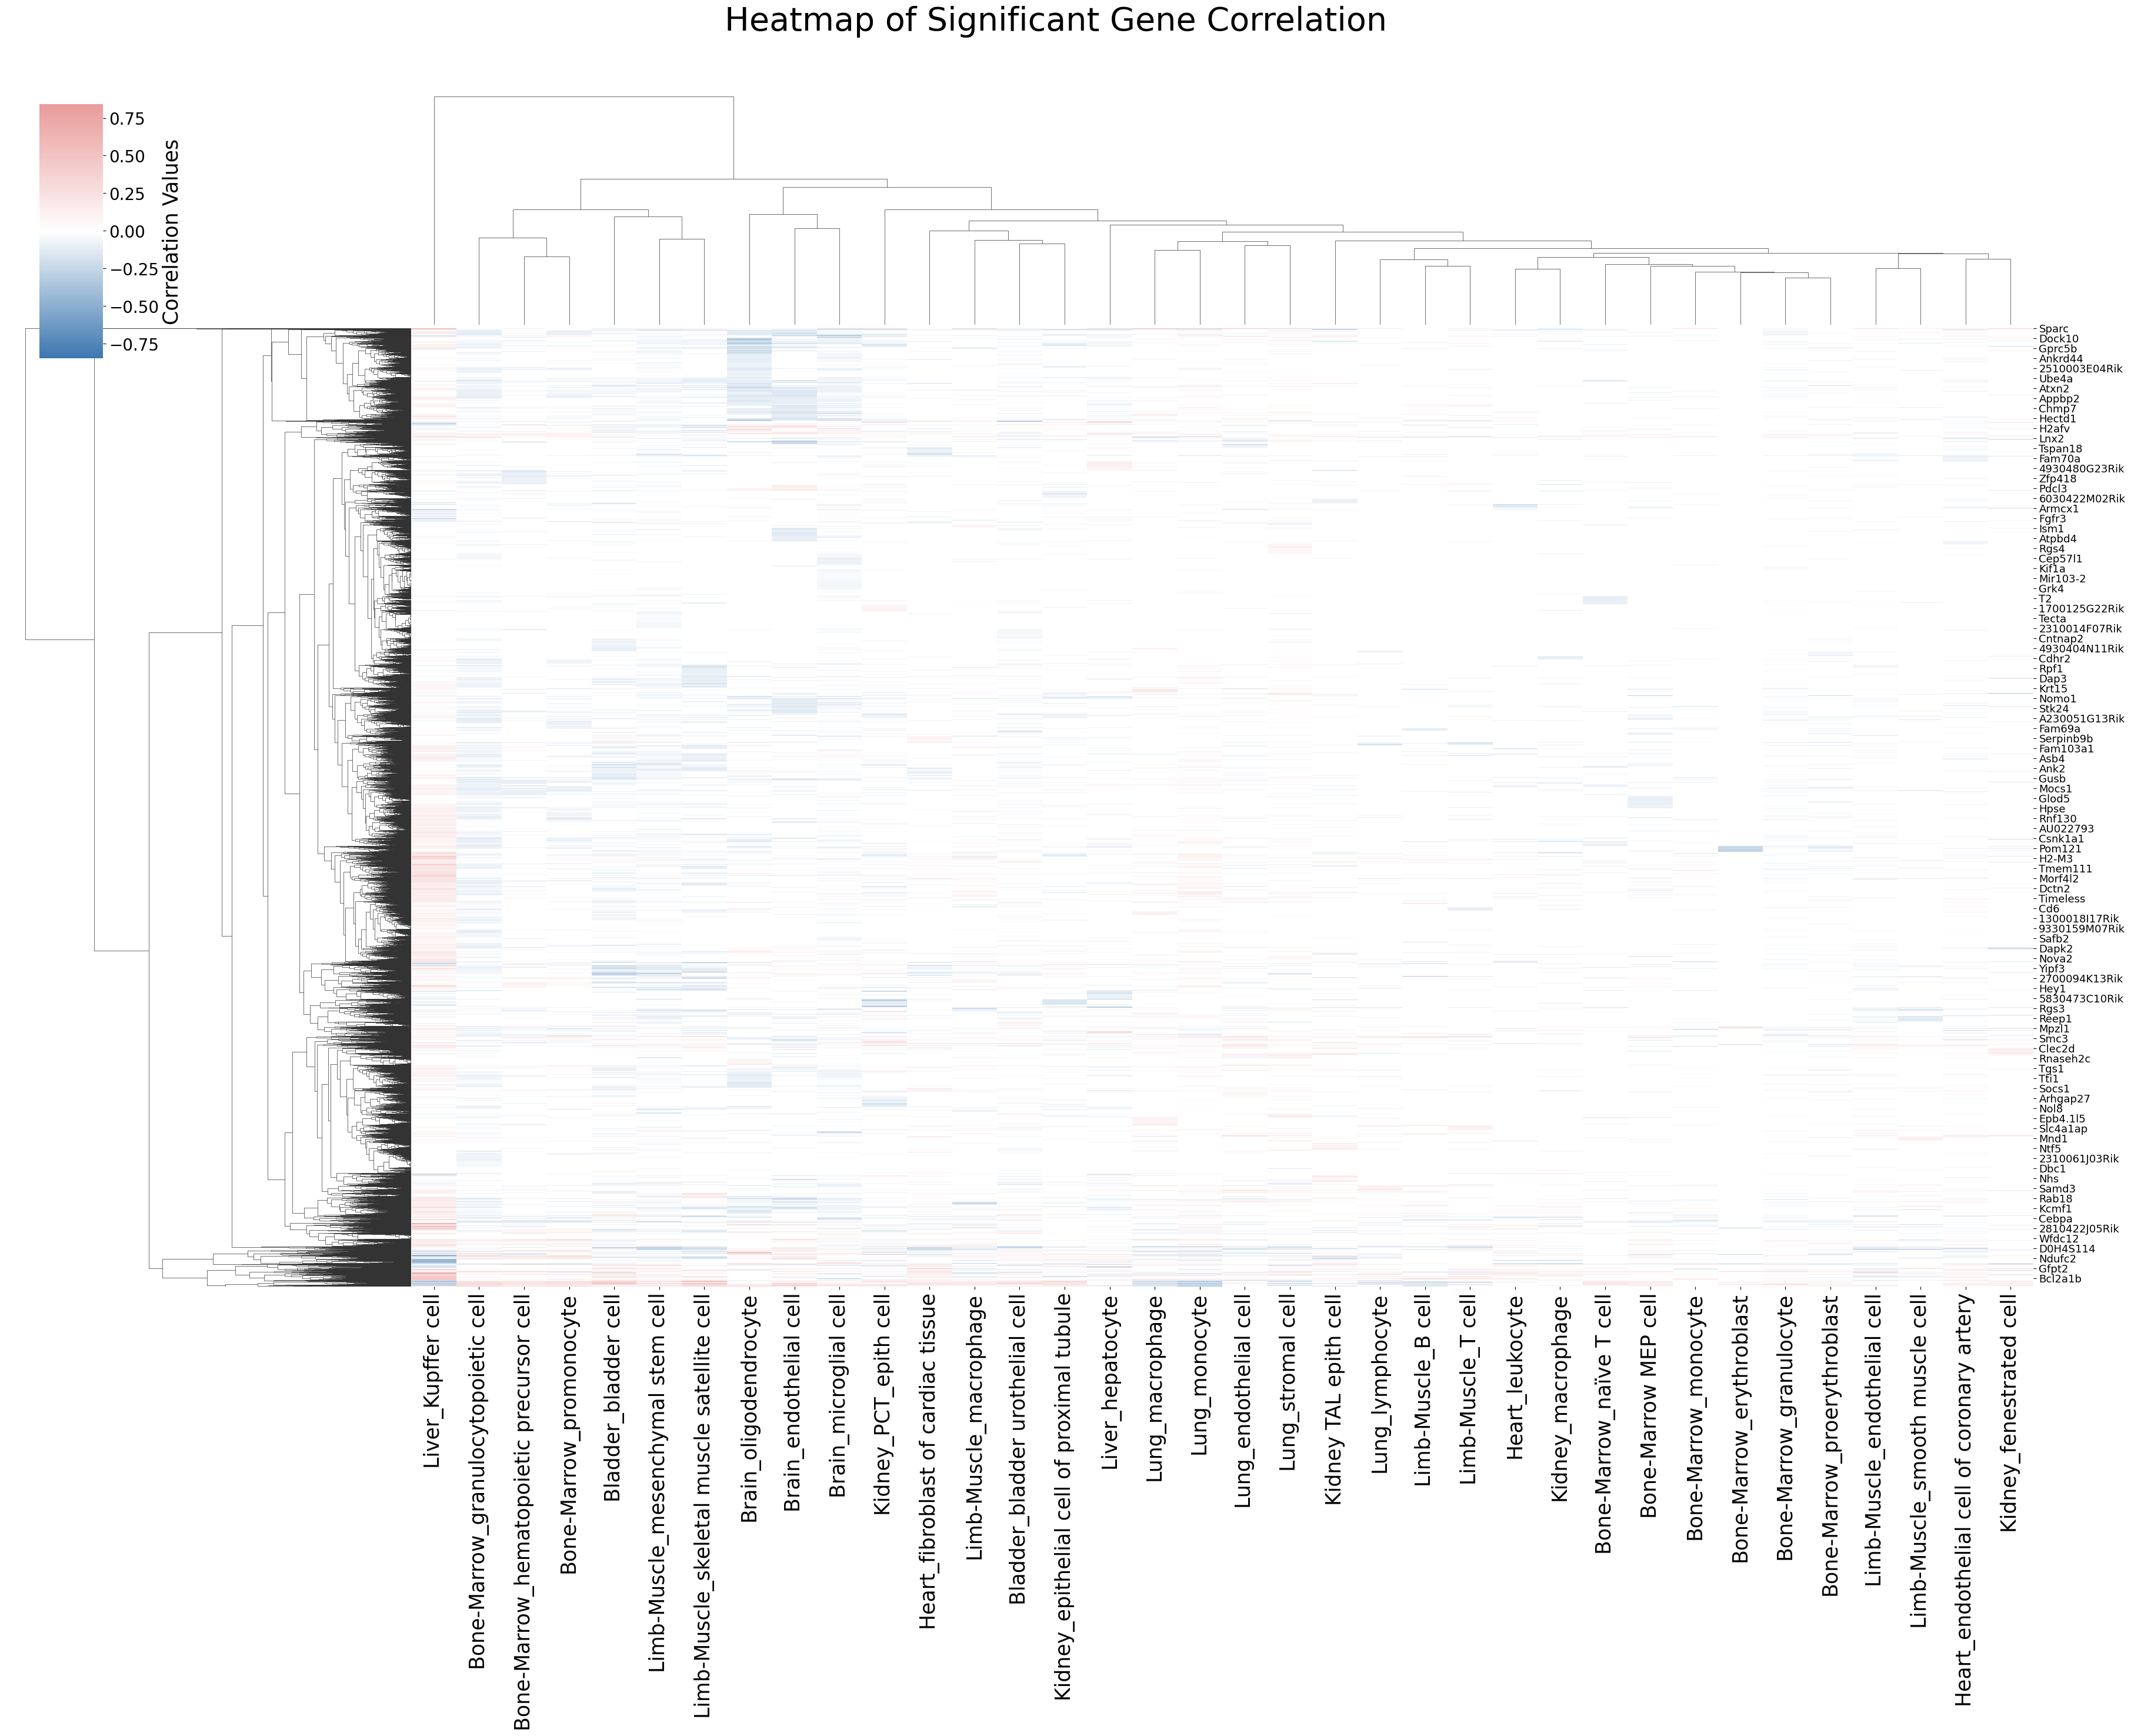

In [13]:
# Plot the heatmap
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list("custom_diverging", ["#3C76AF", "white", "#E89C9A"])
clustermap_dist = sns.clustermap(value_matrix.T, cmap=cmap, 
                                 method='complete', metric='euclidean', figsize=(36, 24))

clustermap_dist.cax.set_position([
    0.02,                         # x-position (further right = less wide)
    clustermap_dist.cax.get_position().y0,
    0.03,                         # width (make this smaller)
    clustermap_dist.cax.get_position().height
])
clustermap_dist.fig.suptitle('Heatmap of Significant Gene Correlation', 
                             fontsize=40, y=1.05)
clustermap_dist.ax_heatmap.set_xlabel("")

clustermap_dist.cax.tick_params(labelsize=20)
plt.ylabel('Correlation Values', fontsize=25)
plt.setp(clustermap_dist.ax_heatmap.get_xticklabels(), fontsize=25)
plt.setp(clustermap_dist.ax_heatmap.get_yticklabels(), fontsize=13)

plt.savefig(f"./Clustermap_of_Gene_Correlation_Filtered_by_adjusted_p_values_across_Celltypes.png", 
            bbox_inches='tight', dpi=300)

plt.show()
plt.close()

In [14]:
result = concatenated.groupby(concatenated.index).agg({
    'log-adjP-values': 'sum',
    'adjP-values': lambda x: list(x),  # Keep the original P-values as lists
    'Category': lambda x: list(x.unique())  # Keep unique categories
})
result = result.rename(columns={"log-adjP-values": "Sum log-adjP-values"})
result['Sum log-adjP-values'].replace(-np.inf, np.nan, inplace=True)
result['Sum log-adjP-values'].fillna(-1e99, inplace=True)
result = result.sort_values(by='Sum log-adjP-values', ascending=True)

In [15]:
result

,Sum log-adjP-values,adjP-values,Category
S100a6,-261.931470,"[1e-10, 1e-10, 0.00014128917087157704, 1e-10, ...","[Bladder_bladder cell, Bladder_bladder urothel..."
Beta-s,-238.575803,"[0.18738182258291652, 0.28886298814542755, 0.8...","[Bladder_bladder cell, Bladder_bladder urothel..."
Rps3a,-235.891449,"[1e-10, 1e-10, 0.42319013985848314, 1e-10, 1e-...","[Bladder_bladder cell, Bladder_bladder urothel..."
Sparc,-234.832829,"[1e-10, 1e-10, 0.1020501499286798, 1.377022102...","[Bladder_bladder cell, Bladder_bladder urothel..."
Rps3,-234.557862,"[1e-10, 1e-10, 0.9925495585734297, 1e-10, 1e-1...","[Bladder_bladder cell, Bladder_bladder urothel..."
...,...,...,...
4930556C24Rik,-0.002834,[0.9934949076535199],[Brain_microglial cell]
4933428C19Rik,-0.002834,[0.9934949076535199],[Brain_microglial cell]
Vmn1r77,-0.002834,[0.9934949076535199],[Brain_microglial cell]
Prss40,-0.002834,[0.9934949076535199],[Brain_microglial cell]


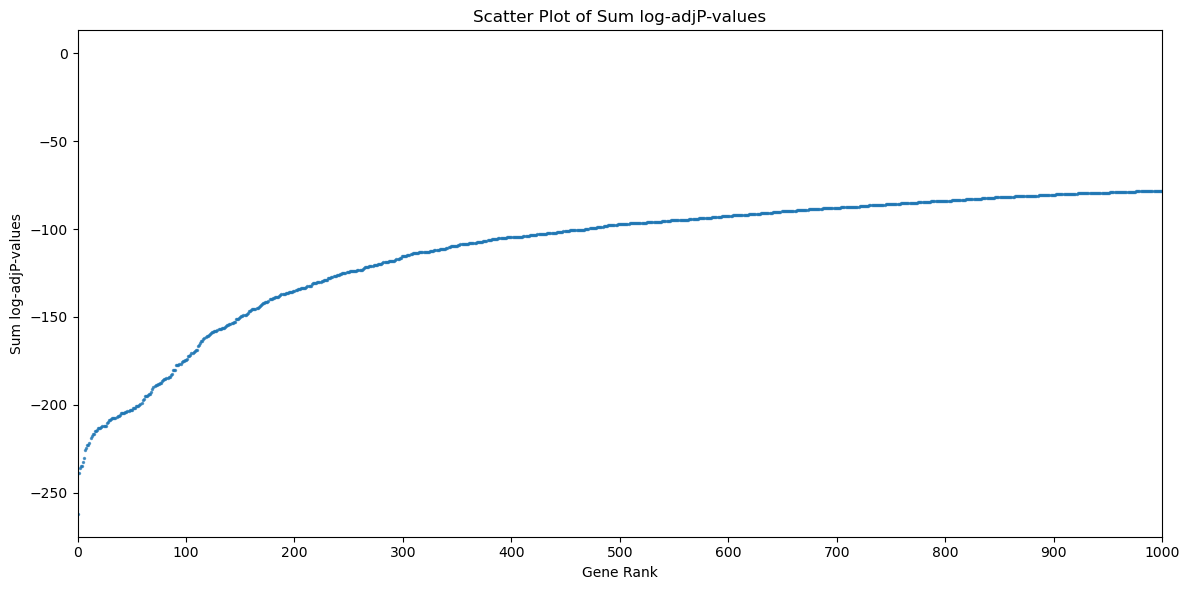

In [16]:
plt.figure(figsize=(12, 6))
plt.scatter(range(len(result)), result["Sum log-adjP-values"], s=2, alpha=0.7)
plt.xlabel("Gene Rank")
plt.ylabel("Sum log-adjP-values")
plt.title("Scatter Plot of Sum log-adjP-values")
plt.xlim(0, 1000)
plt.xticks(range(0, 1001, 100))
plt.tight_layout()
plt.show()

In [17]:
result.to_csv("./all_significant_markers.csv")

In [18]:
sig_counts.loc[result.head(100).index]

,Pearson Correlation,Absolute Correlation,P-values,Category,adjP-values,log-adjP-values
S100a6,0.449696,0.449696,4.060405e-131,Bladder_bladder cell,1.000000e-10,-10.000000
S100a6,0.196104,0.196104,2.156230e-44,Bladder_bladder urothelial cell,1.000000e-10,-10.000000
S100a6,0.361558,0.361558,1.138337e-05,Bone-Marrow_erythroblast,1.412892e-04,-3.849891
S100a6,0.191832,0.191832,2.425573e-59,Bone-Marrow_granulocyte,1.000000e-10,-10.000000
S100a6,0.355033,0.355033,1.674153e-149,Bone-Marrow_granulocytopoietic cell,1.000000e-10,-10.000000
...,...,...,...,...,...,...
H3f3b,0.323279,0.323279,3.212440e-31,Limb-Muscle_skeletal muscle satellite cell,1.000000e-10,-10.000000
H3f3b,0.236625,0.236625,6.779702e-29,Liver_Kupffer cell,1.000000e-10,-10.000000
H3f3b,0.112942,0.112942,3.120078e-06,Liver_hepatocyte,4.364564e-05,-4.360059
H3f3b,-0.105380,0.105380,4.807595e-04,Lung_macrophage,3.934138e-03,-2.405150


In [19]:
pd.options.display.max_rows = 100

In [20]:
result.head(100).to_csv("./Capped_Top100_Sig_Genes_final.csv")

In [21]:
display(result.tail(100))  # Show the last 100 rows

,Sum log-adjP-values,adjP-values,Category
Olfr695,-0.042940,[0.9058574463180684],[Brain_microglial cell]
Atp4b,-0.042940,[0.9058574463180684],[Brain_microglial cell]
Vmn2r78,-0.042940,[0.9058574463180684],[Brain_microglial cell]
Cyp4a30b-ps,-0.042940,[0.9058574463180684],[Brain_microglial cell]
Gm20098,-0.042940,[0.9058574463180684],[Brain_microglial cell]
4930430A15Rik,-0.042940,[0.9058574463180684],[Brain_microglial cell]
Vmn2r73,-0.042940,[0.9058574463180684],[Brain_microglial cell]
Vmn2r10,-0.042940,[0.9058574463180684],[Brain_microglial cell]
Grm2,-0.042940,[0.9058574463180684],[Brain_microglial cell]
Ms4a13,-0.042940,[0.9058574463180684],[Brain_microglial cell]


In [22]:
result.tail(100).to_csv("./Capped_Bottom100_Sig_Genes_final.csv")

In [23]:
top100 = result.head(100)
top100

,Sum log-adjP-values,adjP-values,Category
S100a6,-261.931470,"[1e-10, 1e-10, 0.00014128917087157704, 1e-10, ...","[Bladder_bladder cell, Bladder_bladder urothel..."
Beta-s,-238.575803,"[0.18738182258291652, 0.28886298814542755, 0.8...","[Bladder_bladder cell, Bladder_bladder urothel..."
Rps3a,-235.891449,"[1e-10, 1e-10, 0.42319013985848314, 1e-10, 1e-...","[Bladder_bladder cell, Bladder_bladder urothel..."
Sparc,-234.832829,"[1e-10, 1e-10, 0.1020501499286798, 1.377022102...","[Bladder_bladder cell, Bladder_bladder urothel..."
Rps3,-234.557862,"[1e-10, 1e-10, 0.9925495585734297, 1e-10, 1e-1...","[Bladder_bladder cell, Bladder_bladder urothel..."
Rps7,-232.744314,"[1e-10, 1e-10, 0.6187639538755788, 1e-10, 1e-1...","[Bladder_bladder cell, Bladder_bladder urothel..."
Rps5,-230.159252,"[1e-10, 1e-10, 0.05790994605817409, 3.03722527...","[Bladder_bladder cell, Bladder_bladder urothel..."
Tmsb4x,-225.930247,"[1e-10, 4.19639532236162e-10, 0.47192225717942...","[Bladder_bladder cell, Bladder_bladder urothel..."
Rps20,-224.316640,"[1e-10, 1e-10, 0.3714958467955337, 3.414949928...","[Bladder_bladder cell, Bladder_bladder urothel..."
Rps10,-223.055821,"[1e-10, 1e-10, 0.8769273498387788, 3.642582750...","[Bladder_bladder cell, Bladder_bladder urothel..."


In [24]:
ordered_genes = list(top100.index)

In [25]:
top100_genes_df = top100.explode(['adjP-values', 'Category'])

In [26]:
top100_genes_df['adjP-values'] = top100_genes_df['adjP-values'].fillna(0)

In [27]:
## handle the values that are 0 cause it might result -inf and not showing up in the figure later
top100_genes_df['adjP-values'] = top100_genes_df['adjP-values'].replace(0, 1e-99).astype(float)

top100_genes_df['adjP-values'] = top100_genes_df['adjP-values'].astype(float)

top100_genes_df

,Sum log-adjP-values,adjP-values,Category
S100a6,-261.93147,1.000000e-10,Bladder_bladder cell
S100a6,-261.93147,1.000000e-10,Bladder_bladder urothelial cell
S100a6,-261.93147,1.412892e-04,Bone-Marrow_erythroblast
S100a6,-261.93147,1.000000e-10,Bone-Marrow_granulocyte
S100a6,-261.93147,1.000000e-10,Bone-Marrow_granulocytopoietic cell
...,...,...,...
H3f3b,-174.74851,6.891698e-02,Lung_endothelial cell
H3f3b,-174.74851,8.568239e-02,Lung_lymphocyte
H3f3b,-174.74851,3.934138e-03,Lung_macrophage
H3f3b,-174.74851,1.000000e-10,Lung_monocyte


In [28]:
## reset the index to obtain the gene names
top100_genes_df = top100_genes_df.reset_index()
top100_genes_df

,index,Sum log-adjP-values,adjP-values,Category
0,S100a6,-261.93147,1.000000e-10,Bladder_bladder cell
1,S100a6,-261.93147,1.000000e-10,Bladder_bladder urothelial cell
2,S100a6,-261.93147,1.412892e-04,Bone-Marrow_erythroblast
3,S100a6,-261.93147,1.000000e-10,Bone-Marrow_granulocyte
4,S100a6,-261.93147,1.000000e-10,Bone-Marrow_granulocytopoietic cell
...,...,...,...,...
3582,H3f3b,-174.74851,6.891698e-02,Lung_endothelial cell
3583,H3f3b,-174.74851,8.568239e-02,Lung_lymphocyte
3584,H3f3b,-174.74851,3.934138e-03,Lung_macrophage
3585,H3f3b,-174.74851,1.000000e-10,Lung_monocyte


In [29]:
# Pivot the data to create a matrix with genes (index) as rows, categories as columns, and adjP-values as values
heatmap_data = top100_genes_df.pivot_table(index='index', columns='Category', values='adjP-values')

# Reorder the rows in the heatmap_data DataFrame according to the original order in ordered_genes
heatmap_data = heatmap_data.reindex(ordered_genes)

# Apply -log10 transformation to highlight significant p-values
log_p_values = -np.log10(heatmap_data)

In [30]:
log_p_values

Category,Bladder_bladder cell,Bladder_bladder urothelial cell,Bone-Marrow_erythroblast,Bone-Marrow_granulocyte,Bone-Marrow_granulocytopoietic cell,Bone-Marrow_hematopoietic precursor cell,Bone-Marrow_megakaryocyte-erythroid progenitor cell,Bone-Marrow_monocyte,Bone-Marrow_naïve T cell,Bone-Marrow_proerythroblast,...,Limb-Muscle_mesenchymal stem cell,Limb-Muscle_skeletal muscle satellite cell,Limb-Muscle_smooth muscle cell,Liver_Kupffer cell,Liver_hepatocyte,Lung_endothelial cell,Lung_lymphocyte,Lung_macrophage,Lung_monocyte,Lung_stromal cell
index,,,,,,,,,,,,,,,,,,,,,
S100a6,10.000000,10.000000,3.849891,10.000000,10.000000,10.000000,10.000000,0.904407,10.000000,10.000000,...,10.000000,7.089859,8.485072,9.183642,3.254296,0.276467,10.000000,0.208218,10.000000,10.000000
Beta-s,0.727273,0.539308,0.066308,10.000000,10.000000,10.000000,2.607929,0.076243,10.000000,4.198738,...,10.000000,1.790871,0.902575,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
Rps3a,10.000000,10.000000,0.373464,10.000000,10.000000,9.404565,4.549992,0.342937,6.746550,6.965712,...,10.000000,10.000000,0.011430,10.000000,0.406242,0.290592,8.325927,10.000000,10.000000,5.897580
Sparc,10.000000,10.000000,0.991186,5.861059,10.000000,1.508207,1.188106,0.152643,0.503977,0.848670,...,10.000000,10.000000,10.000000,8.863217,1.084817,10.000000,3.294911,10.000000,10.000000,10.000000
Rps3,10.000000,10.000000,0.003248,10.000000,10.000000,10.000000,4.537975,0.112260,6.906696,10.000000,...,10.000000,10.000000,0.403326,10.000000,0.677497,0.218092,6.566296,10.000000,10.000000,4.230162
Rps7,10.000000,10.000000,0.208475,10.000000,10.000000,7.341363,3.737852,0.043995,6.395958,2.754023,...,10.000000,10.000000,0.644649,10.000000,2.621593,0.290116,6.925037,10.000000,10.000000,10.000000
Rps5,10.000000,10.000000,1.237247,8.517523,10.000000,10.000000,6.557158,0.162857,7.053230,6.534819,...,10.000000,10.000000,0.006546,10.000000,4.244786,0.465508,4.474819,10.000000,10.000000,7.037043
Tmsb4x,10.000000,9.377124,0.326130,10.000000,10.000000,10.000000,10.000000,0.327151,8.295470,10.000000,...,10.000000,3.146271,2.297920,10.000000,4.006986,0.735762,0.029947,10.000000,10.000000,10.000000
Rps20,10.000000,10.000000,0.430046,8.466616,10.000000,8.970549,3.585398,1.518628,5.281680,4.095332,...,10.000000,10.000000,0.152851,10.000000,0.141399,0.584989,9.493668,10.000000,10.000000,4.084355


In [31]:
log_p_values_sorted = log_p_values.sort_index()
log_p_values_sorted

Category,Bladder_bladder cell,Bladder_bladder urothelial cell,Bone-Marrow_erythroblast,Bone-Marrow_granulocyte,Bone-Marrow_granulocytopoietic cell,Bone-Marrow_hematopoietic precursor cell,Bone-Marrow_megakaryocyte-erythroid progenitor cell,Bone-Marrow_monocyte,Bone-Marrow_naïve T cell,Bone-Marrow_proerythroblast,...,Limb-Muscle_mesenchymal stem cell,Limb-Muscle_skeletal muscle satellite cell,Limb-Muscle_smooth muscle cell,Liver_Kupffer cell,Liver_hepatocyte,Lung_endothelial cell,Lung_lymphocyte,Lung_macrophage,Lung_monocyte,Lung_stromal cell
index,,,,,,,,,,,,,,,,,,,,,
AW112010,1.460719,6.029063,0.280772,5.740324,5.463074,3.364185,1.028207,10.000000,4.386178,1.320523,...,10.000000,2.730557,0.252681,10.000000,10.000000,0.390409,10.000000,0.110090,10.000000,0.442349
B2m,10.000000,10.000000,0.592047,10.000000,10.000000,4.591931,2.175539,1.419726,7.890096,0.080750,...,10.000000,10.000000,6.092793,3.426823,10.000000,2.846122,0.027811,1.185903,10.000000,0.917436
Beta-s,0.727273,0.539308,0.066308,10.000000,10.000000,10.000000,2.607929,0.076243,10.000000,4.198738,...,10.000000,1.790871,0.902575,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
Ccl5,8.225558,10.000000,0.962722,10.000000,10.000000,4.883096,3.475181,4.060142,5.471598,10.000000,...,10.000000,0.468296,0.537880,10.000000,10.000000,7.750363,10.000000,3.039572,10.000000,4.743591
Cd74,0.390046,5.152100,0.151824,2.969206,0.011628,0.196760,0.433705,10.000000,2.199053,0.282246,...,10.000000,2.253009,1.137575,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
Dbp,10.000000,10.000000,NaN,2.545999,9.956791,4.056779,0.960189,1.252307,0.581358,2.073186,...,10.000000,10.000000,10.000000,4.094132,4.015892,10.000000,1.038976,1.569177,5.328590,10.000000
Ddit4,0.201329,10.000000,0.030108,0.922019,0.451524,10.000000,0.213847,10.000000,5.169443,0.953623,...,10.000000,0.380385,0.603192,10.000000,2.222255,6.134120,3.524643,0.178194,10.000000,0.467561
Fau,10.000000,10.000000,0.114882,10.000000,10.000000,10.000000,4.864713,0.057609,9.207224,7.526420,...,10.000000,10.000000,0.070600,10.000000,1.527806,1.867788,1.569562,8.625645,10.000000,5.297009
Fth1,10.000000,10.000000,0.016785,10.000000,10.000000,9.014130,3.115652,0.859452,8.024922,6.753589,...,10.000000,10.000000,0.428583,1.061292,3.186943,1.709559,0.297996,0.499319,3.825093,10.000000


In [32]:
log_p_values_sorted = log_p_values_sorted.rename(
    columns={"Kidney_kidney loop of Henle thick ascending limb epithelial cell": "Kidney_TAL epith cell",
          "Bone-Marrow_megakaryocyte-erythroid progenitor cell": "Bone-Marrow_MEP cell",
          "Kidney_kidney proximal convoluted tubule epithelial cell": "Kidney_PCT-epith cell"}
)

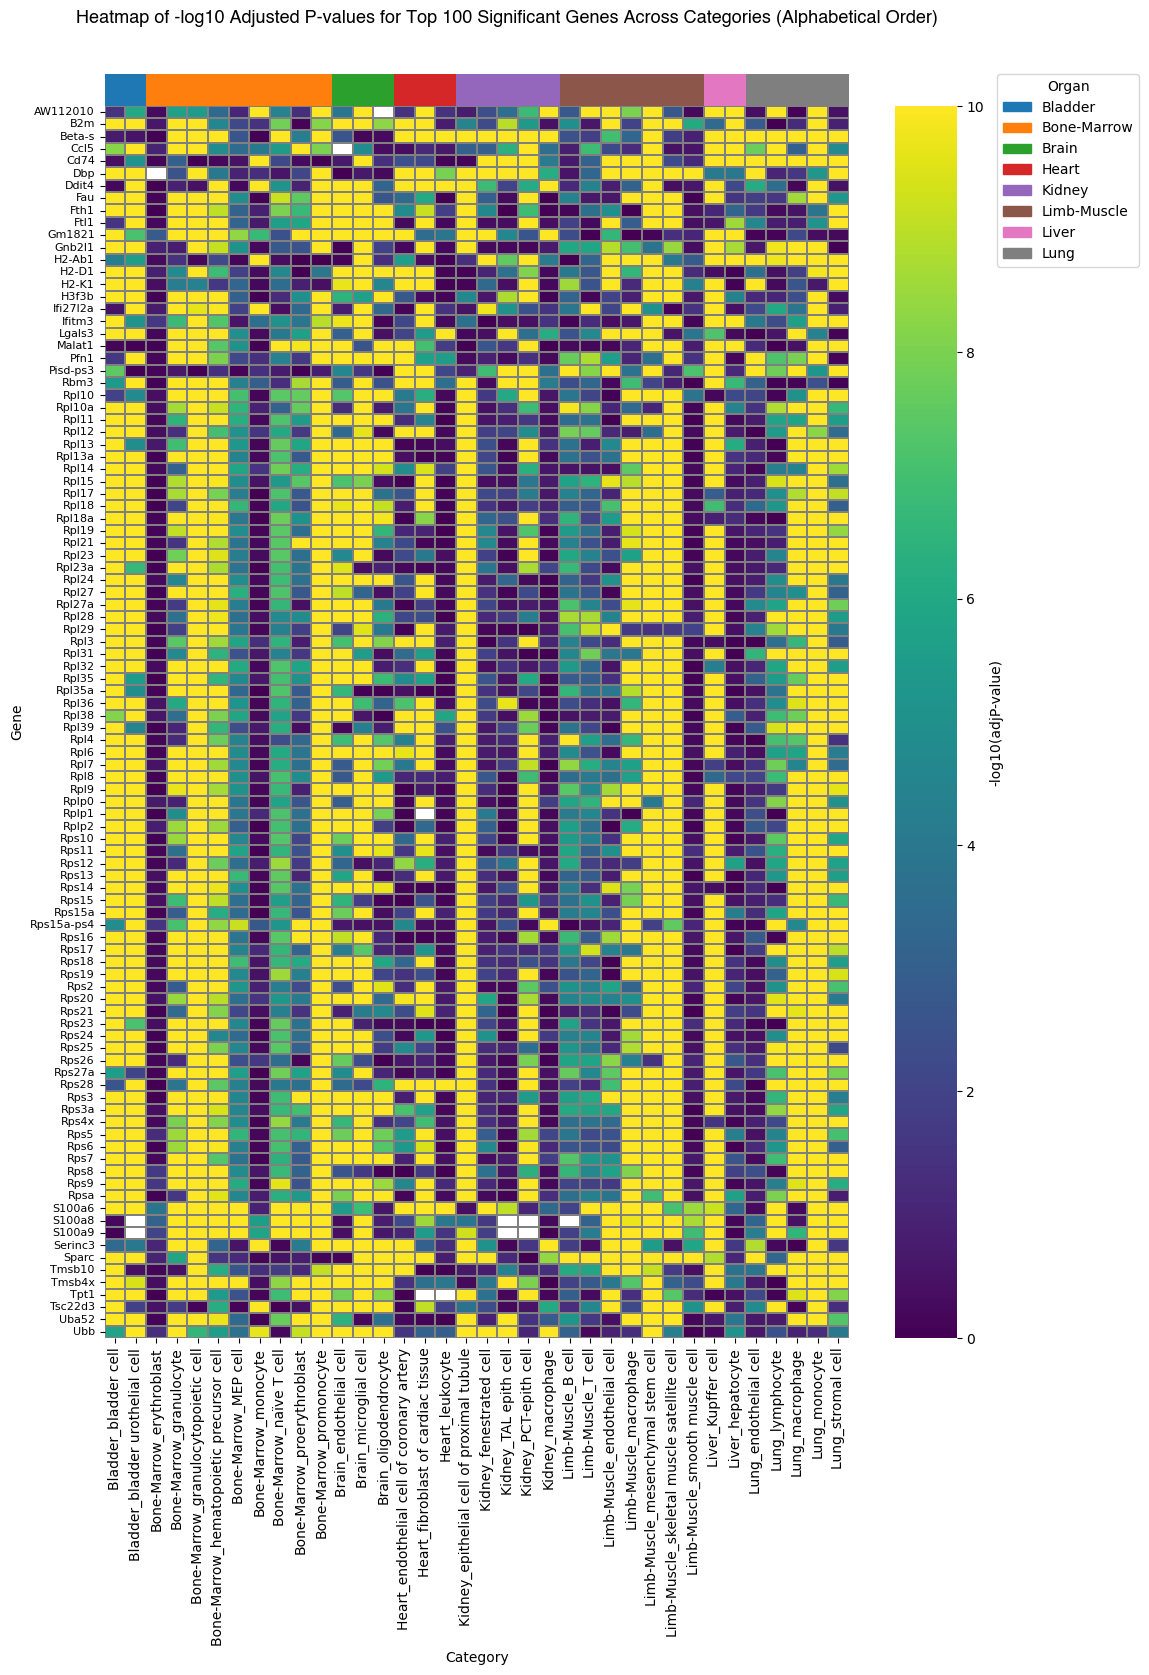

In [33]:
base_cmap = sns.color_palette("viridis", as_cmap=True)
colors = base_cmap(np.linspace(0, 1, 256))
custom_cmap = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(12, 16))
ax.tick_params(axis='y', labelsize=8)
sns.heatmap(
    log_p_values_sorted, cmap=custom_cmap, cbar_kws={'label': '-log10(adjP-value)'},
    linewidths=0.1, linecolor='grey', xticklabels=True, yticklabels=True,
    mask=log_p_values_sorted.isna(), ax=ax, vmin=0
)

heatmap_pos = ax.get_position()
bar_height = 0.02  # Height of the annotation bar
top_ax = fig.add_axes([heatmap_pos.x0, heatmap_pos.y1, heatmap_pos.width, bar_height])

organ_names = log_p_values_sorted.columns.str.split('_').str[0]
unique_organs = organ_names.unique()
palette = sns.color_palette("tab10", len(unique_organs))
organ_color_map = dict(zip(unique_organs, palette))
organ_colors_rgb = np.array([organ_color_map[organ] for organ in organ_names], dtype=float)

top_ax.imshow([organ_colors_rgb], aspect="auto", interpolation="nearest")
top_ax.set_xticks(np.arange(len(organ_colors_rgb)) + 0.5, minor=True)
top_ax.grid(which="minor", color="grey", linestyle="-", linewidth=0.5)
top_ax.tick_params(which="minor", size=0)
top_ax.axis("off")

legend_patches = [mpatches.Patch(color=color, label=organ) for organ, color in organ_color_map.items()]
plt.legend(handles=legend_patches, title="Organ", bbox_to_anchor=(1.2, 1), loc='upper left', borderaxespad=0.)

plt.suptitle('Heatmap of -log10 Adjusted P-values for Top 100 Significant Genes Across Categories (Alphabetical Order)', x=0.46, y=0.94, fontname="helvetica", fontsize=13)
ax.set_xlabel('Category')
ax.set_ylabel('Gene')
plt.setp(ax.get_xticklabels(), rotation=90)

fig.savefig("Top100_Sig_Genes_-log10_values_ranked_by_sum_without_extreme_highlight.png", bbox_inches='tight', dpi = 600)
plt.show()

## Plotting the summaries of categories

In [46]:
classifications = pd.read_csv("./Top100gene_categories_July.csv")
classifications

,Gene,Category
0,S100a6,Immune response
1,Beta-s,Other / uncategorized
2,Rps3a,Ribosomal protein
3,Sparc,Extracellular matrix / adhesion
4,Rps3,Ribosomal protein
5,Rps7,Ribosomal protein
6,Rps5,Ribosomal protein
7,Tmsb4x,Actin cytoskeleton / cytoskeletal regulation
8,Rps20,Ribosomal protein
9,Rps10,Ribosomal protein


In [47]:
class_sum = np.sum(pd.crosstab(classifications["Gene"], classifications["Category"]), axis = 0)
df = (
    class_sum.astype(int)
             .sort_values(ascending=True)
             .rename_axis("Category")
             .reset_index(name="count")
)
df["percent"] = df["count"] / df["count"].sum() * 100

In [48]:
df

,Category,count,percent
0,Extracellular matrix / adhesion,1,1.0
1,"Galectin (lectin family, ECM/immune)",1,1.0
2,Iron metabolism (ferritin),1,1.0
3,Lipid metabolism / membrane protein,1,1.0
4,Signaling (G protein-related),1,1.0
5,Ubiquitin system,2,2.0
6,Actin cytoskeleton / cytoskeletal regulation,3,3.0
7,Histocompatibility Complex Proteins,4,4.0
8,Other / uncategorized,5,5.0
9,Transcription / stress,6,6.0


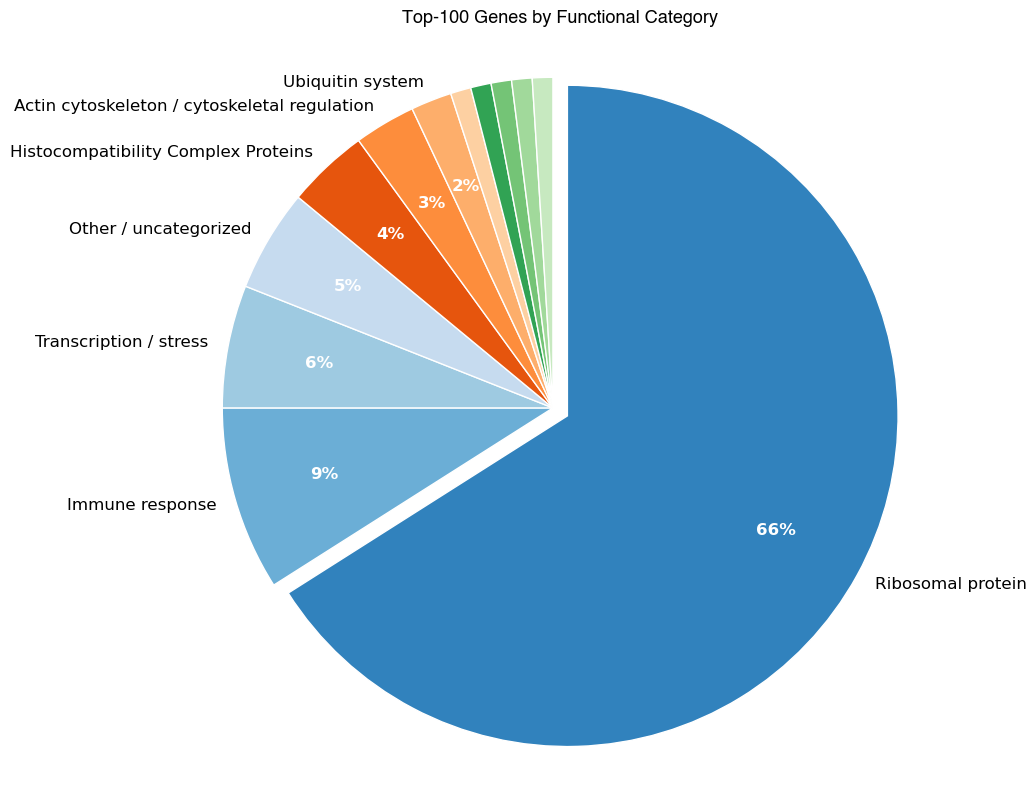

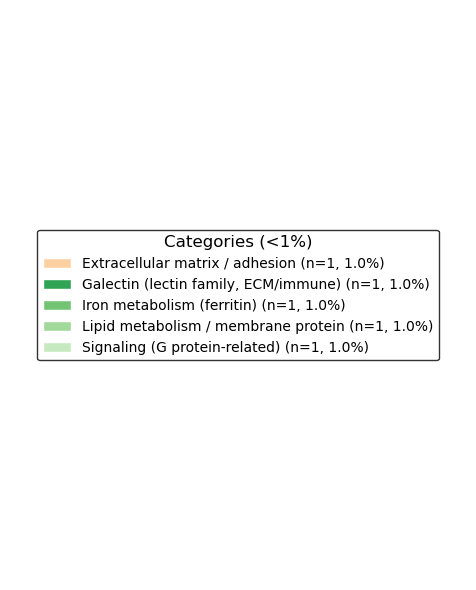

In [51]:
threshold = 1.5  # % cutoff for labeling on the pie

d = df.copy().sort_values("percent", ascending=False).reset_index(drop=True)
explode = [0.05 if i == 0 else 0 for i in range(len(d))]

colors = plt.cm.tab20c.colors[:len(d)]

# Create main pie chart figure (without legend)
fig, ax = plt.subplots(figsize=(10, 8))

def autopct_fmt(pct):
    return f"{pct:.0f}%" if pct >= threshold else ""

pie_labels = [cat if pct >= threshold else "" 
              for cat, pct in zip(d["Category"], d["percent"])]

wedges, texts, autotexts = ax.pie(
    d["percent"],
    labels=pie_labels,
    autopct=autopct_fmt,
    startangle=90,
    counterclock=False,
    explode=explode,
    colors=colors,
    wedgeprops=dict(edgecolor="white", linewidth=1),
    labeldistance=1.06,   # nudge labels a touch outward
    pctdistance=0.72      # keep % inside the wedge
)

for t in texts:
    t.set_fontsize(12)
for at in autotexts:
    at.set_fontsize(12)
    at.set_color("white")
    at.set_weight("bold")

ax.set_title("Top-100 Genes by Functional Category", fontsize=13, fontname="helvetica", pad=15)
ax.axis("equal")
plt.tight_layout()  # Changed from rect=[0, 0, 1, 0.75]
plt.savefig("Classification_pie_top100_no_legend.png", dpi=600, bbox_inches="tight")
plt.show()

# Create separate legend figure
mask_small = d["percent"] < threshold
small_idx = [i for i, m in enumerate(mask_small) if m]

if len(small_idx) > 0:  # Only create legend if there are small categories
    legend_handles = [wedges[i] for i in small_idx]
    legend_labels = [f"{d.loc[i,'Category']} (n={int(d.loc[i,'count'])}, {d.loc[i,'percent']:.1f}%)"
                    for i in small_idx]
    
    # Create figure for legend only
    fig_legend = plt.figure(figsize=(5, 6))
    ax_legend = fig_legend.add_subplot(111)
    ax_legend.axis('off')
    
    # Create the legend
    legend = ax_legend.legend(
        legend_handles, legend_labels,
        title=f"Categories (<{int(threshold)}%)",
        title_fontsize=12,
        fontsize=10,
        loc="center",
        frameon=True,
        fancybox=True,
        shadow=False
    )
    
    # Style the legend
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('black')
    legend.get_frame().set_linewidth(1)
    
    # Save legend figure
    plt.tight_layout()
    plt.savefig("Classification_pie_legend_only.png", dpi=600, bbox_inches="tight")
    plt.show()